# BIG MART DATA SALES ANALYSIS

In [2]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt 
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [5]:
# IGNORE ALL WARNINGS
from warnings import filterwarnings
warnings=filterwarnings("ignore")

In [6]:
data=pd.read_csv('Train.csv') 

In [7]:
data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [8]:
data.shape

(8523, 12)

## 1). DATA CLEANING

In [9]:
# check the null values
data.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [11]:
#check the mean,min,max in your data
data.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [12]:
#check the mean,min,max in item weight
data['Item_Weight'].describe()

count    7060.000000
mean       12.857645
std         4.643456
min         4.555000
25%         8.773750
50%        12.600000
75%        16.850000
max        21.350000
Name: Item_Weight, dtype: float64

### Item weight is numerical value so we can fill it with mean imputation

In [13]:
data['Item_Weight'].fillna(data['Item_Weight'].mean(),inplace=True)

### Outlet_Size is categorical value so we can fill it with mode imputation

In [14]:
data['Outlet_Size'].value_counts()

Outlet_Size
Medium    2793
Small     2388
High       932
Name: count, dtype: int64

In [16]:
data['Outlet_Size'].fillna(data['Outlet_Size'].mode()[0],inplace=True)

In [17]:
#now you can check null values is filled
data.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

#### view some basic details about dataset

In [18]:
#view unique items of Outlet_Establishment_Year
print(data['Outlet_Establishment_Year'].unique())

[1999 2009 1998 1987 1985 2002 2007 1997 2004]


In [19]:
#view unique items of Outlet_Size
print(data['Outlet_Size'].unique())

['Medium' 'High' 'Small']


In [20]:
#view unique items of Item_Type
data['Item_Type'].unique()

array(['Dairy', 'Soft Drinks', 'Meat', 'Fruits and Vegetables',
       'Household', 'Baking Goods', 'Snack Foods', 'Frozen Foods',
       'Breakfast', 'Health and Hygiene', 'Hard Drinks', 'Canned',
       'Breads', 'Starchy Foods', 'Others', 'Seafood'], dtype=object)

In [21]:
#view unique items of Outlet_Type
data['Outlet_Type'].unique()

array(['Supermarket Type1', 'Supermarket Type2', 'Grocery Store',
       'Supermarket Type3'], dtype=object)

In [22]:
#view unique items of Item_Fat_Content
data['Item_Fat_Content'].unique()

array(['Low Fat', 'Regular', 'low fat', 'LF', 'reg'], dtype=object)

In [23]:
#change the names of Item_fat_content
data['Item_Fat_Content'].replace(['LF', 'low fat', 'reg'], 
         ['Low Fat','Low Fat','Regular'],inplace=True)

In [24]:
#vie all columns names 
data.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

In [25]:
# drop unnecessary columns
data.drop(['Item_Identifier','Outlet_Location_Type'
          ,'Outlet_Identifier','Item_Visibility'],axis=1)

,Item_Weight,Item_Fat_Content,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Type,Item_Outlet_Sales
0,9.300,Low Fat,Dairy,249.8092,1999,Medium,Supermarket Type1,3735.1380
1,5.920,Regular,Soft Drinks,48.2692,2009,Medium,Supermarket Type2,443.4228
2,17.500,Low Fat,Meat,141.6180,1999,Medium,Supermarket Type1,2097.2700
3,19.200,Regular,Fruits and Vegetables,182.0950,1998,Medium,Grocery Store,732.3800
4,8.930,Low Fat,Household,53.8614,1987,High,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...
8518,6.865,Low Fat,Snack Foods,214.5218,1987,High,Supermarket Type1,2778.3834
8519,8.380,Regular,Baking Goods,108.1570,2002,Medium,Supermarket Type1,549.2850
8520,10.600,Low Fat,Health and Hygiene,85.1224,2004,Small,Supermarket Type1,1193.1136
8521,7.210,Regular,Snack Foods,103.1332,2009,Medium,Supermarket Type2,1845.5976


# some methods of eda

In [1]:
#using dtale
'''(pip install dtale) use this for install
import dtale
d= dtale.show(data)
dtale.instances()'''
#using pandas profiling
'''pip install 
https://github.com/pandas-profiling/pandas-profiling/archive/master.zip
import pandas_profiling
profile= pandas_profiling.ProfileReport(data)'''
# using data pred
''''(pip install dataprep) use this for install
from dataprep.eda import create_report
create_report(data)'''

"'(pip install dataprep) use this for install\nfrom dataprep.eda import create_report\ncreate_report(data)"

### use sweetviz for show your report in html form

In [23]:
# (pip install sweetviz) use this for install
'''import sweetviz as sv
my_report = sv.analyze(data)
report = my_report.show_html()'''

'import sweetviz as sv\nmy_report = sv.analyze(data)\nreport = my_report.show_html()'

# 2).DataVisualization

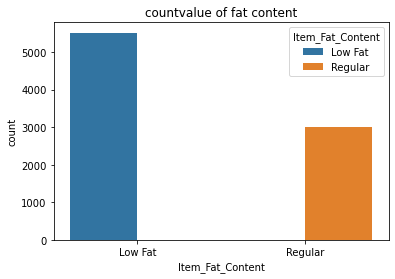

In [24]:
#countplot of Item_Fat_content
plt.figure(figsize=(6,4))
sns.countplot(x='Item_Fat_Content' , data=data,hue='Item_Fat_Content' )
plt.xlabel('Item_Fat_Content')
plt.title('countvalue of fat content')
plt.show()

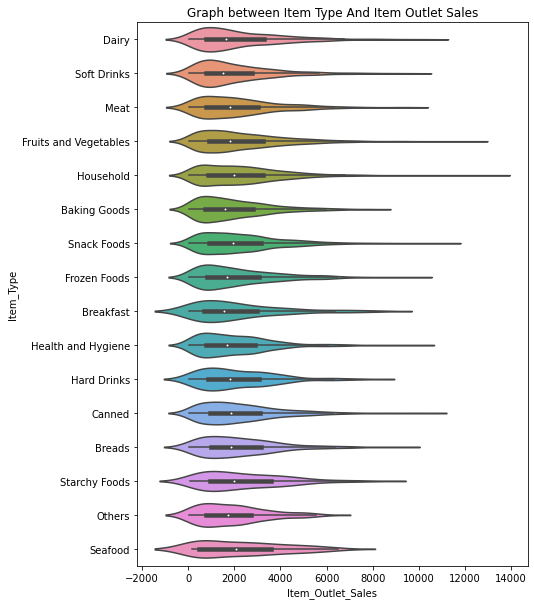

In [25]:
#Graph between Item Type And Item Outlet Sales
plt.figure(figsize=(7,10)) 
sns.violinplot(data=data,x='Item_Outlet_Sales',y='Item_Type') 
plt.title('Graph between Item Type And Item Outlet Sales')
plt.show()

*from the above graph we conclude that

*household type things were highly sold out

#### distribution of the variable outlet_size

Text(0.5, 1.0, 'Item_0utlet_Sales Distribution')

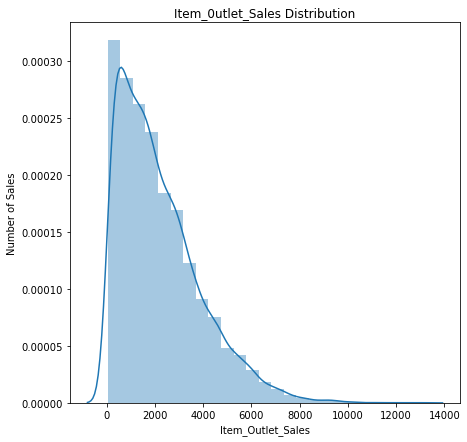

In [26]:
plt.figure(figsize=(7,7)) 
sns.distplot(data.Item_Outlet_Sales,bins=25) 
plt.xlabel("Item_Outlet_Sales") 
plt.ylabel("Number of Sales")
plt.title("Item_0utlet_Sales Distribution")

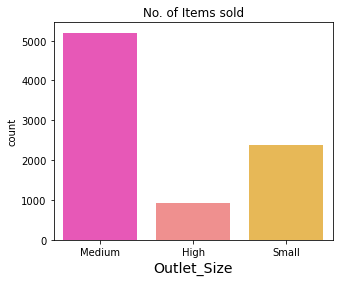

In [27]:
#showing the size of items
plt.figure(figsize=(5,4))
sns.countplot(x='Outlet_Size' , data=data,palette='spring')
plt.xlabel('Outlet_Size', fontsize=14)
plt.title('No. of Items sold')
plt.show()

Medium Sized Items--Highly Sold

##### graph of highest sale value

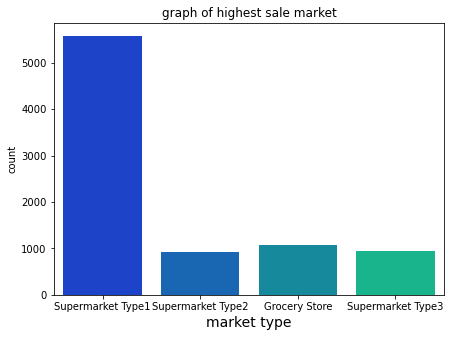

In [28]:
#graph of highest sale value
plt.figure(figsize=(7,5))
sns.countplot(x='Outlet_Type', data=data,palette='winter')
plt.xlabel('market type', fontsize=14)
plt.title('graph of highest sale market')
plt.show()

from the above graph we conclude that Supermarket Type
1 is the highest outlet type market

### Outlet Establishment Year and Item Outlet Sales

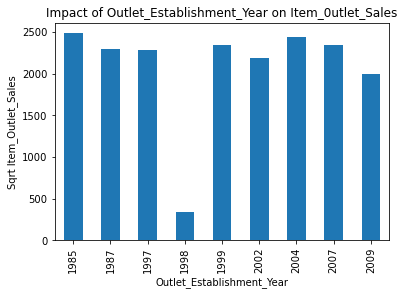

In [29]:
data.groupby('Outlet_Establishment_Year')['Item_Outlet_Sales'].mean().plot.bar()
plt.xlabel("Outlet_Establishment_Year")
plt.ylabel("Sqrt Item_Outlet_Sales")
plt.title("Impact of Outlet_Establishment_Year on Item_0utlet_Sales")
plt.show()

#### pie chart that shows the item_Type & Item_Outlet_Sales

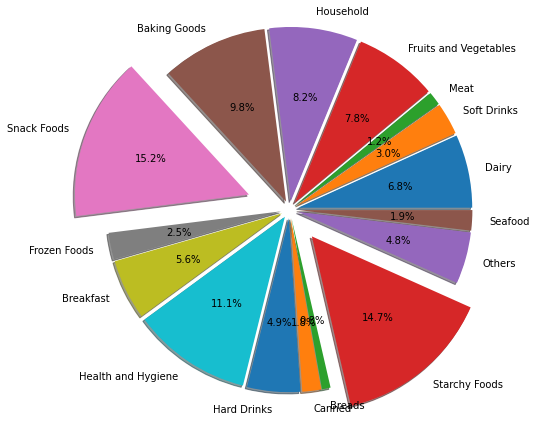

In [30]:
#shows the sale of Item_Type in percentage
fm1=data.groupby(by='Item_Type').sum()
fm=fm1['Item_Outlet_Sales']
plt.pie(fm, autopct = '%0.1f%%', radius = 2.0, 
labels =['Dairy', 'Soft Drinks', 'Meat', 'Fruits and Vegetables',
       'Household', 'Baking Goods', 'Snack Foods', 'Frozen Foods',
       'Breakfast', 'Health and Hygiene', 'Hard Drinks', 'Canned',
       'Breads', 'Starchy Foods', 'Others', 'Seafood'],
        explode = [0.1,0.1,0.1,0.1,0.1,0.1,0.5,0.1,0.1,
                   0.1,0.1,0.1,0.1,0.4,0.1,0.1],shadow=True)
plt.show()

# correlation

In [31]:
data.corr()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
Item_Weight,1.000000,-0.012049,0.024756,-0.008301,0.011550
Item_Visibility,-0.012049,1.000000,-0.001315,-0.074834,-0.128625
Item_MRP,0.024756,-0.001315,1.000000,0.005020,0.567574
Outlet_Establishment_Year,-0.008301,-0.074834,0.005020,1.000000,-0.049135
Item_Outlet_Sales,0.011550,-0.128625,0.567574,-0.049135,1.000000


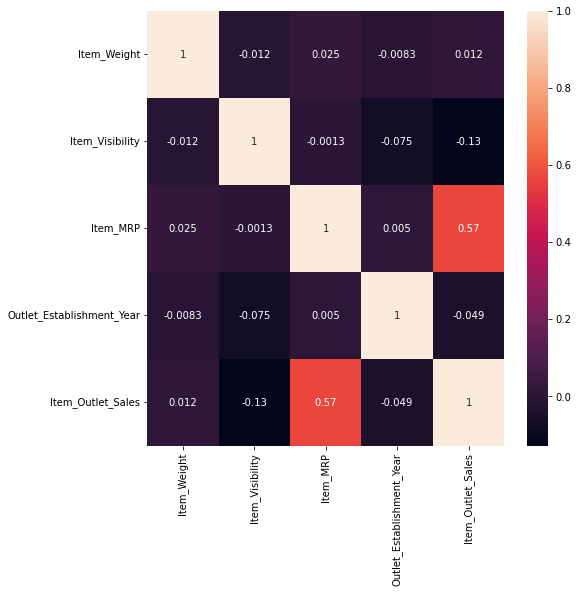

In [32]:
#data correlation
plt.figure(figsize=(8,8))
sns.heatmap(data.corr(),annot=True)
plt.show()

### selecting features based on general requirement

In [33]:
data.drop(['Item_Identifier','Outlet_Identifier'],axis=1,inplace=True)

# 3).preprocessing task before model building

#### a) label encodding

In [34]:
from sklearn.preprocessing import LabelEncoder

In [35]:
le= LabelEncoder()

In [36]:
data=data.apply(le.fit_transform)

In [37]:
data

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,284,0,664,4,5592,4,1,0,1,2540
1,57,1,880,14,473,8,1,2,2,422
2,376,0,715,10,2901,4,1,0,1,1639
3,393,1,0,6,4227,3,1,2,0,670
4,265,0,0,9,627,1,0,2,1,865
...,...,...,...,...,...,...,...,...,...,...
8518,125,0,3912,13,4955,1,0,2,1,2047
8519,233,1,3278,0,2023,5,1,1,1,516
8520,299,0,2302,8,1263,6,2,1,1,1018
8521,149,1,7175,13,1857,8,1,2,2,1466


#### b) splitting our data into train and test

In [38]:
from sklearn.model_selection import train_test_split

In [39]:
x=data.drop('Item_Outlet_Sales',axis=1)

In [40]:
#showning columns name of x
x.columns

Index(['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type',
       'Item_MRP', 'Outlet_Establishment_Year', 'Outlet_Size',
       'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')

In [41]:
x.shape

(8523, 9)

In [42]:
y=data['Item_Outlet_Sales']

In [43]:
y.shape

(8523,)

In [44]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=3,test_size=0.2)

In [45]:
data.shape

(8523, 10)

In [46]:
y_test.shape

(1705,)

#### c) standarization

In [47]:
#you see that you data is not standerdize
x_train.describe()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
count,6818.000000,6818.000000,6818.000000,6818.000000,6818.000000,6818.000000,6818.000000,6818.000000,6818.000000
mean,298.148724,0.353036,3715.789088,7.242006,2958.314022,3.813435,1.170871,1.110003,1.197565
std,95.863604,0.477949,2403.836586,4.211071,1674.212731,2.731135,0.600466,0.813512,0.789479
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,284.000000,0.000000,1594.500000,4.000000,1556.500000,1.000000,1.000000,0.000000,1.000000
50%,326.000000,0.000000,3718.000000,6.000000,2981.500000,4.000000,1.000000,1.000000,1.000000
75%,361.000000,1.000000,5814.750000,10.000000,4375.000000,6.000000,2.000000,2.000000,1.000000
max,415.000000,1.000000,7879.000000,15.000000,5937.000000,8.000000,2.000000,2.000000,3.000000


In [48]:
#standerdization is used to noralize our data 
from sklearn.preprocessing import StandardScaler
sc= StandardScaler()

In [49]:
#we use fit_transform because we have to learn the data
x_train_std=sc.fit_transform(x_train)

In [50]:
#we use tranform because after learning we dont want data leakage
x_test_std=sc.transform(x_test)

In [51]:
x_train_std

array([[ 0.24882254,  1.35372511,  0.47394838, ..., -0.28458515,
         1.0940992 ,  1.01648507],
       [ 1.16686078, -0.73870241, -0.68802946, ...,  1.38090972,
        -1.36455879, -0.25026602],
       [-0.10587405, -0.73870241,  0.70401417, ...,  1.38090972,
        -0.1352298 , -0.25026602],
       ...,
       [ 0.69740941, -0.73870241, -0.62021621, ..., -0.28458515,
         1.0940992 , -1.51701711],
       [ 0.29055155,  1.35372511,  1.19534816, ..., -0.28458515,
         1.0940992 ,  2.28323616],
       [-0.08500955, -0.73870241,  1.66671261, ..., -0.28458515,
         1.0940992 , -1.51701711]])

In [52]:
x_test_std

array([[ 1.02080924, -0.73870241,  0.66865144, ..., -1.95008002,
         1.0940992 , -0.25026602],
       [ 0.22795803, -0.73870241,  0.83797653, ...,  1.38090972,
        -0.1352298 , -0.25026602],
       [-0.07457729, -0.73870241, -1.35825728, ..., -0.28458515,
         1.0940992 ,  1.01648507],
       ...,
       [-2.06713756, -0.73870241,  0.89538897, ...,  1.38090972,
        -1.36455879, -0.25026602],
       [ 0.29055155,  1.35372511, -1.1955887 , ..., -0.28458515,
         1.0940992 ,  2.28323616],
       [ 0.24882254, -0.73870241,  0.0629086 , ..., -0.28458515,
        -1.36455879, -0.25026602]])

In [53]:
y_train.head()

7708    2951
4369     931
5978    2638
4117     229
5291    2633
Name: Item_Outlet_Sales, dtype: int64

In [54]:
y_test.head()

4258    2100
2574    1948
517      358
3004     762
2159     145
Name: Item_Outlet_Sales, dtype: int64

#### d) model building

In [55]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

In [56]:
lr.fit(x_train_std,y_train)

LinearRegression()

In [57]:
y_pred_lr=lr.predict(x_test_std)

In [58]:
y_pred_lr.shape

(1705,)

In [59]:
y_pred_lr

array([1696.53375952, 1039.11532651, 1094.23390965, ..., 1969.71204   ,
       1699.77684825, 1033.55439761])

## 4) Evaluation using Linear regressor

In [60]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [61]:
print('mean_absolute_error:- ',mean_absolute_error(y_test,y_pred_lr))
print('r2_score:-            ',r2_score(y_test,y_pred_lr))
print('RMSE value:-          ',np.sqrt(mean_squared_error(y_test,y_pred_lr)))

mean_absolute_error:-  477.9858904633177
r2_score:-             0.5829985235005208
RMSE value:-           599.4950981614279


## 5) Evaluation using random forest regressor

In [2]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=3)

In [63]:
rf.fit(x_train,y_train)

RandomForestRegressor(random_state=3)

In [64]:
y_pred_rf =rf.predict(x_test)

In [65]:
y_pred_rf

array([2080.77, 1361.46,  680.88, ..., 2185.83, 1390.85,  768.96])

In [66]:
y_pred_rf.shape

(1705,)

In [67]:
print('mean_absolute_error:- ',mean_absolute_error(y_test,y_pred_rf))
print('r2_score:-            ',r2_score(y_test,y_pred_rf))
print('Rmse value:-          ',np.sqrt(mean_squared_error(y_test,y_pred_rf)))

mean_absolute_error:-  417.9643988269795
r2_score:-             0.6536310037610501
Rmse value:-           546.369371481759


# 6) Actual vs Predicted sales graph

Text(0.5, 1.0, 'Actual vs Predicted Data by linear regression')

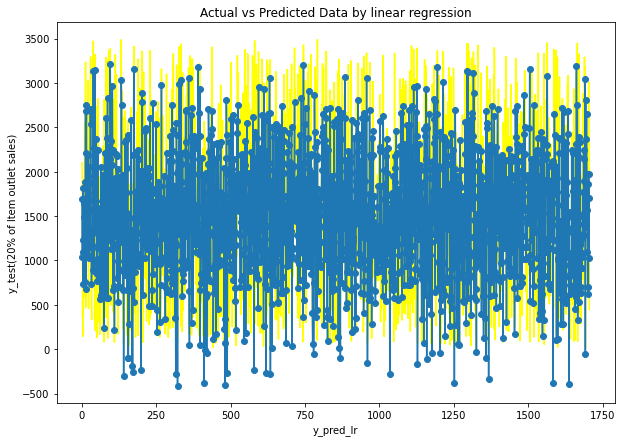

In [68]:
#graphh of prediction by using linear regression
plt.figure(figsize=(10,7))
c=[i for i in range(1,1706)]
plt.plot(c,y_test,color='yellow') 
plt.plot(c,y_pred_lr,marker='o')
plt.xlabel('y_pred_lr')
plt.ylabel('y_test(20% of Item outlet sales)')
plt.title("Actual vs Predicted Data by linear regression")

Text(0.5, 1.0, 'Actual vs Predicted Data by random forest regressor')

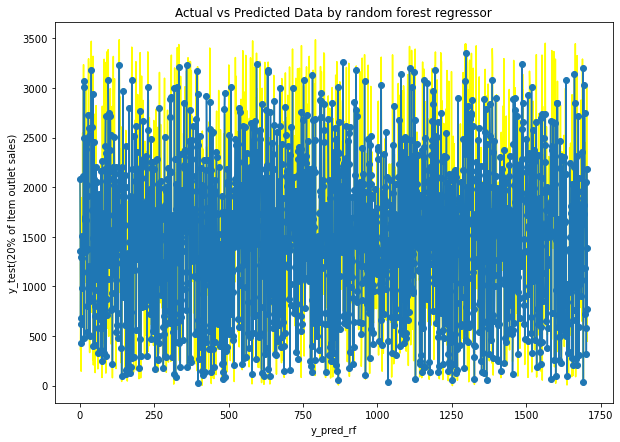

In [69]:
#graphh of prediction by using random forest regressor
plt.figure(figsize=(10,7))
c=[i for i in range(1,1706)]
plt.plot(c,y_test,color='yellow') 
plt.plot(c,y_pred_rf,marker='o')
plt.xlabel('y_pred_rf')
plt.ylabel('y_test(20% of Item outlet sales)')
plt.title("Actual vs Predicted Data by random forest regressor")